In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data3,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_3D,net_3D_fix,S_valgrad,error_general_3D,main_fix
CUDA_LAUNCH_BLOCKING=2

def f_y(x, x_min,x_max,y_min,y_max,z_min,z_max,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1) 
    
    # Apply the piecewise function
    f_y_values = np.where(r_y < r, r - r_y, 0.0)
    return f_y_values

def ana_S(x,x_min,x_max,y_min,y_max,z_min,z_max,a,b,r): #x为数据，a，b均为中心点
    return f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,a,r)-f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,b,r)

    

cuda:2


In [2]:
import copy
Nx,Ny,Nz=1,1,1
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81]
tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max=0,1,0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max=-0.5,1.5,-0.5,1.5,-0.5,1.5 #边界gamma处
num_batches_gauss=1
b_n=10
points_b=mea_3D.generate_cube_surface(b_x_min,b_x_max,b_y_min,b_y_max,b_z_min,b_z_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_1=np.array([0.3,0.5,0.3])
center_2=np.array([0.5,0.5,0.8])
center_true=np.array([[0.3,0.5,0.3],[0.5,0.5,0.8]])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
num_batches_gauss=4
num_batches_appr=10
num_batches_mea=1
cupy_device = 2

In [ ]:
F_81_5_15=np.load("./noise=5%/F_81_5%.npy")

In [7]:
M=3600
af="Tanh"   #先用tanh
R_m=10
models0 = net_3D_fix.local_rep(in_features=3, out_features=1, hidden_layers=1, M=M, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=[], r_max=[],b1_min=[],b1_max=[],b2_min=[],b2_max=[],b3_min=[],b3_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af=af,device=device).to(device)

Plotting 64 cells. Levels: 0 to 0


/mnt/store/hxw-y23/3D/two_sources/自适应/../main_code2/main_fix.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


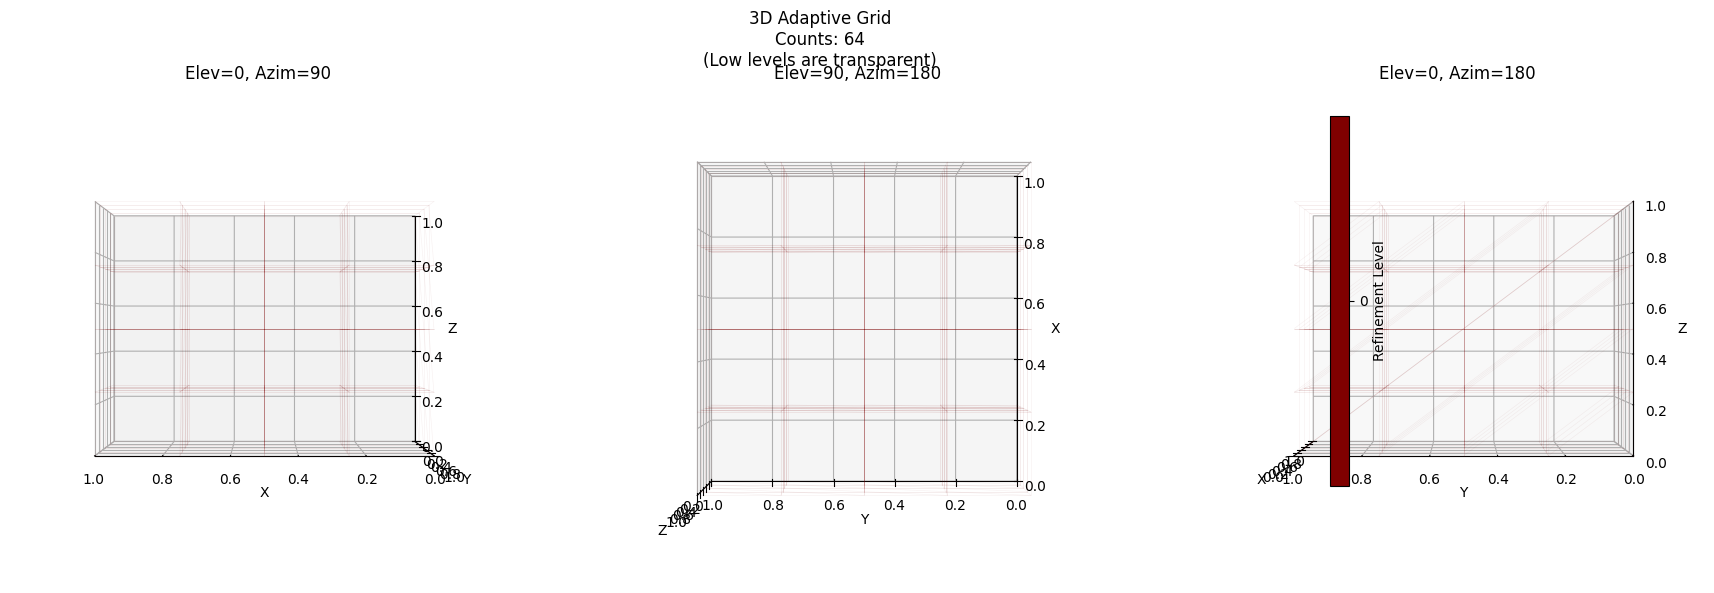

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


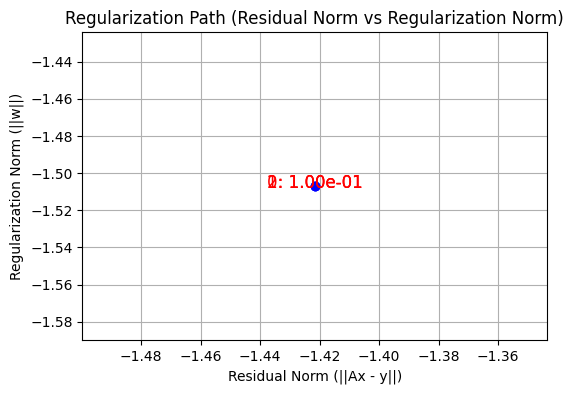

第 0 次迭代的train误差：
S_l_inf= 5.472631584041574 S_L_2= 0.012764359303838764 S_l_2= 0.7147680353023582
第 0 次迭代的泛化误差：


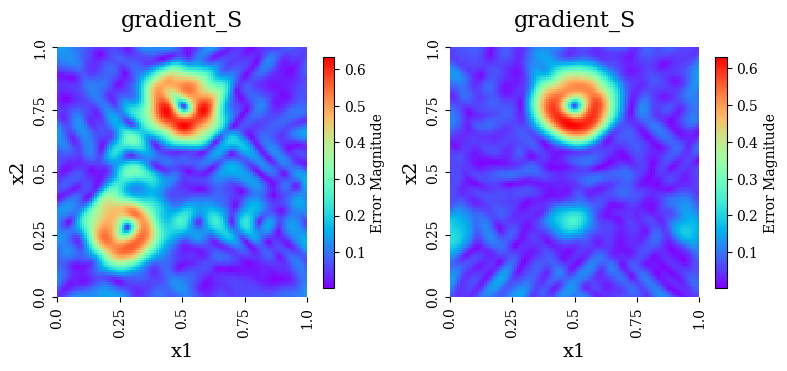

S_l_inf= 8.732209492710451 S_L_2= 0.011975300995722016 S_l_2= 0.7423900846950876


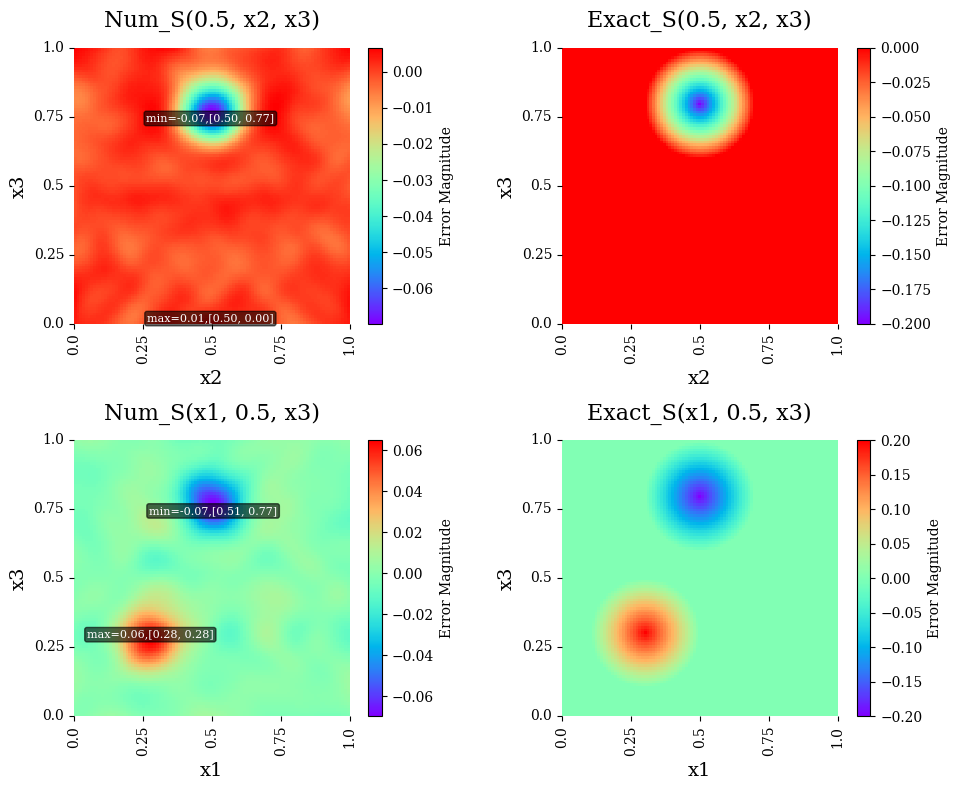

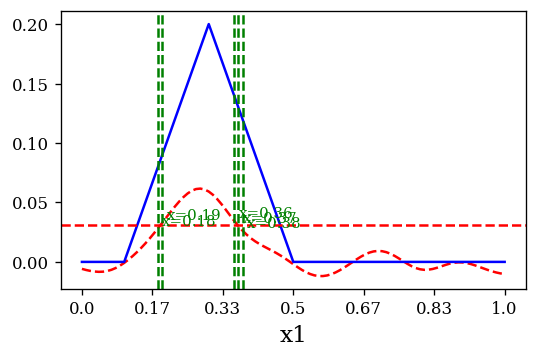

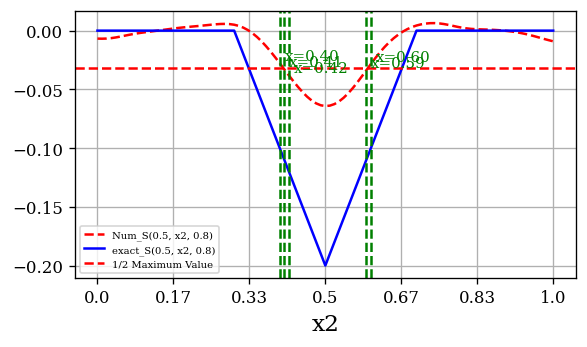

第 0 次自适应网格细分...
S_l_inf= 5.472631584041574 S_L_2= 0.012764359303838764 S_l_2= 0.7147680353023582
S_l_inf= 7.728828801195479 S_L_2= 0.012162078628153918 S_l_2= 0.7423373061159904
当前总网格数目: 491
Visualization failed: name 'MeshVisualizer' is not defined
Plotting 491 cells. Levels: 0 to 1


/mnt/store/hxw-y23/3D/two_sources/自适应/../main_code2/main_fix.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


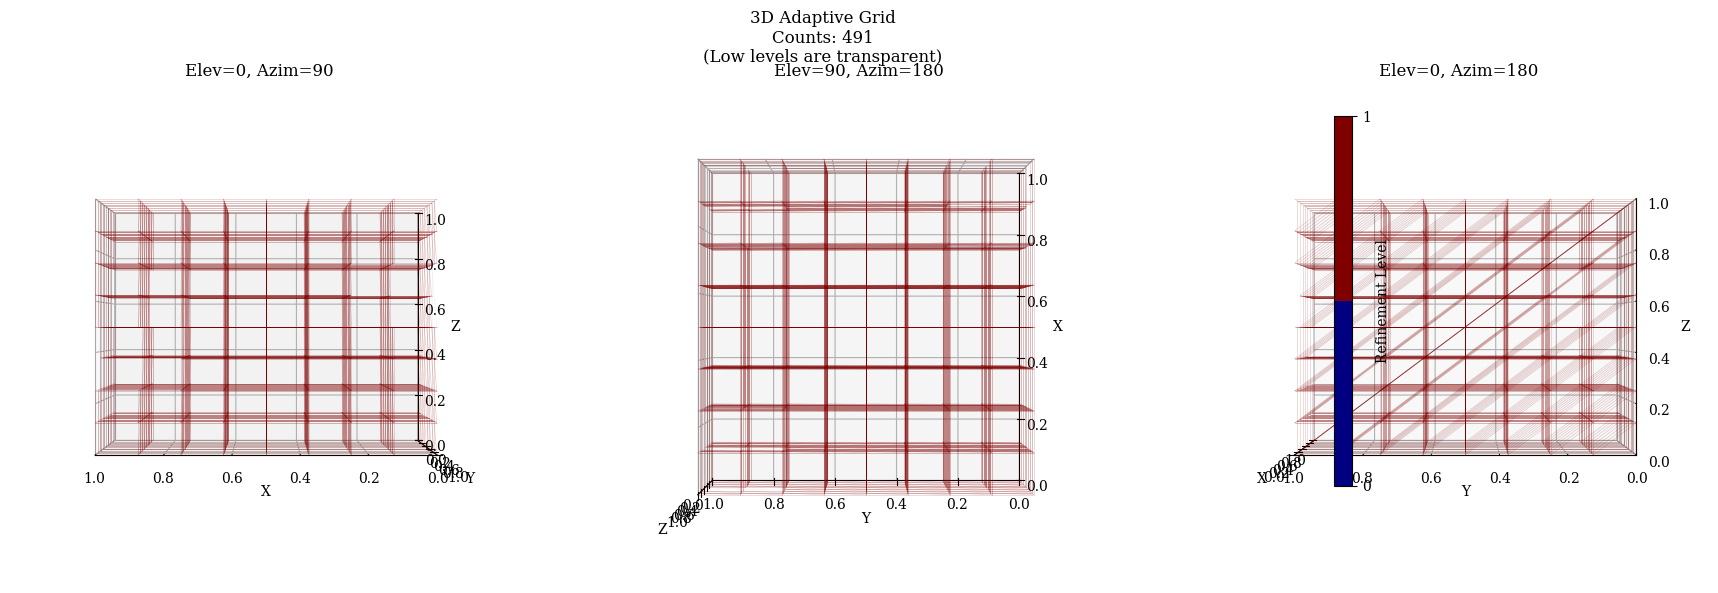

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


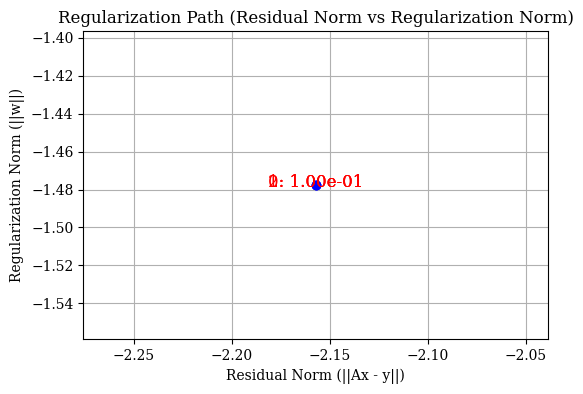

第 1 次迭代的train误差：
S_l_inf= 1.2205533705939173 S_L_2= 0.002020503727958395 S_l_2= 0.12076995414033859
第 1 次迭代的泛化误差：


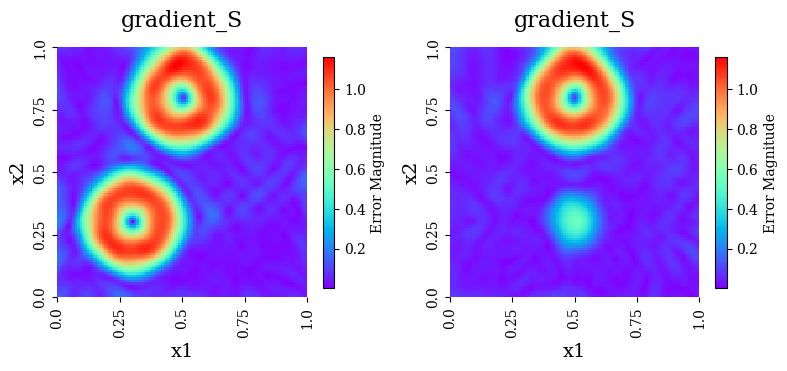

S_l_inf= 2.4282535032750694 S_L_2= 0.0019214796759251627 S_l_2= 0.11911913194161555


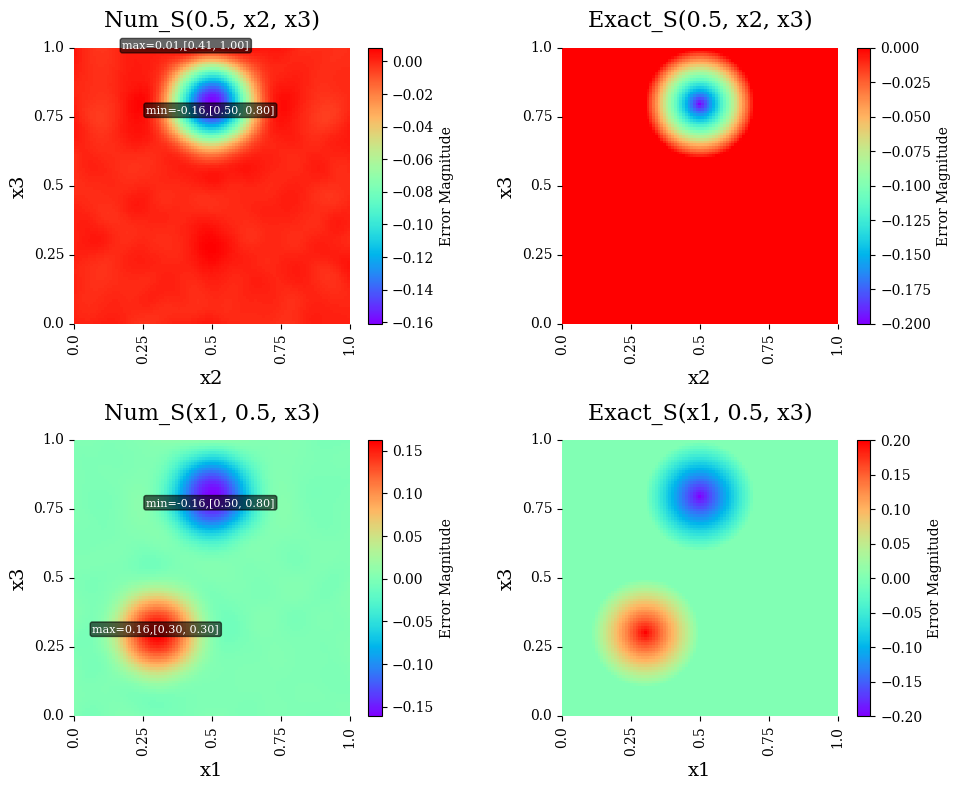

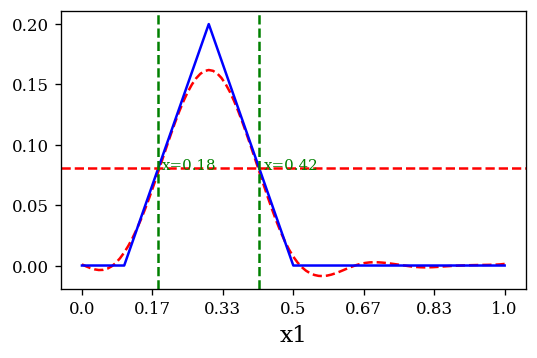

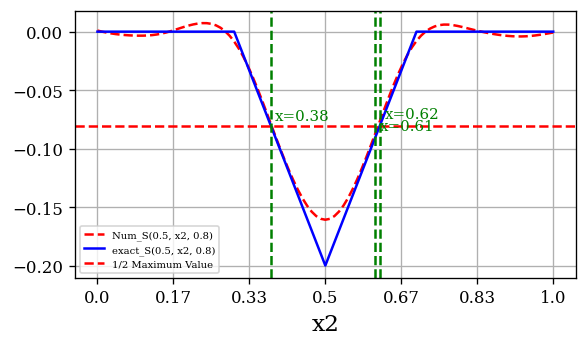

第 1 次自适应网格细分...
S_l_inf= 1.2205533705939173 S_L_2= 0.002020503727958395 S_l_2= 0.12076995414033859
S_l_inf= 1.7443638827897272 S_L_2= 0.001976485254767941 S_l_2= 0.11818140167336383
当前总网格数目: 1436
Visualization failed: name 'MeshVisualizer' is not defined
Plotting 1436 cells. Levels: 0 to 2


/mnt/store/hxw-y23/3D/two_sources/自适应/../main_code2/main_fix.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


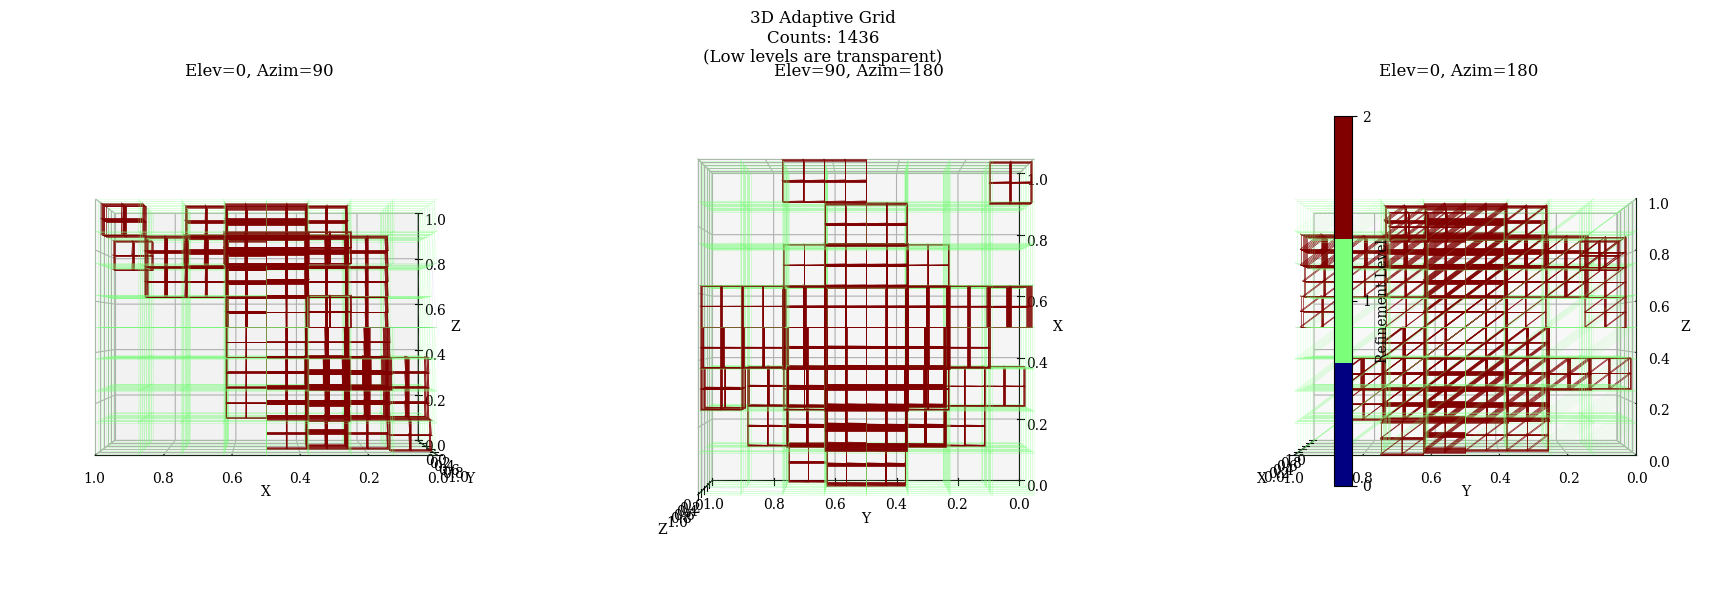

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


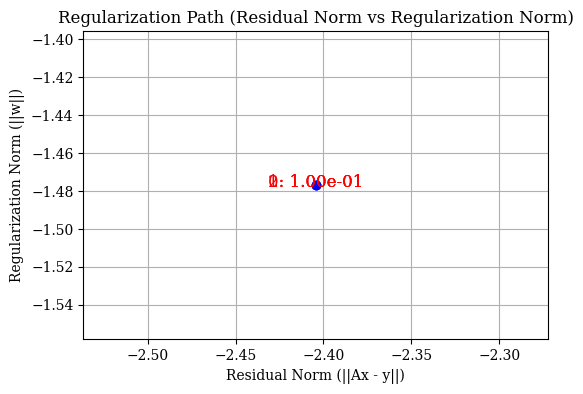

第 2 次迭代的train误差：
S_l_inf= 0.851670341776331 S_L_2= 0.00239185540681641 S_l_2= 0.0864736056652998
第 2 次迭代的泛化误差：


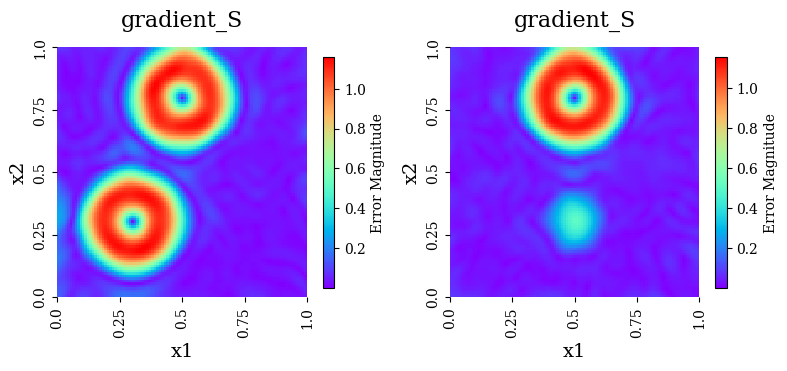

S_l_inf= 2.0950099056437312 S_L_2= 0.0015510074442234584 S_l_2= 0.09615228446375607


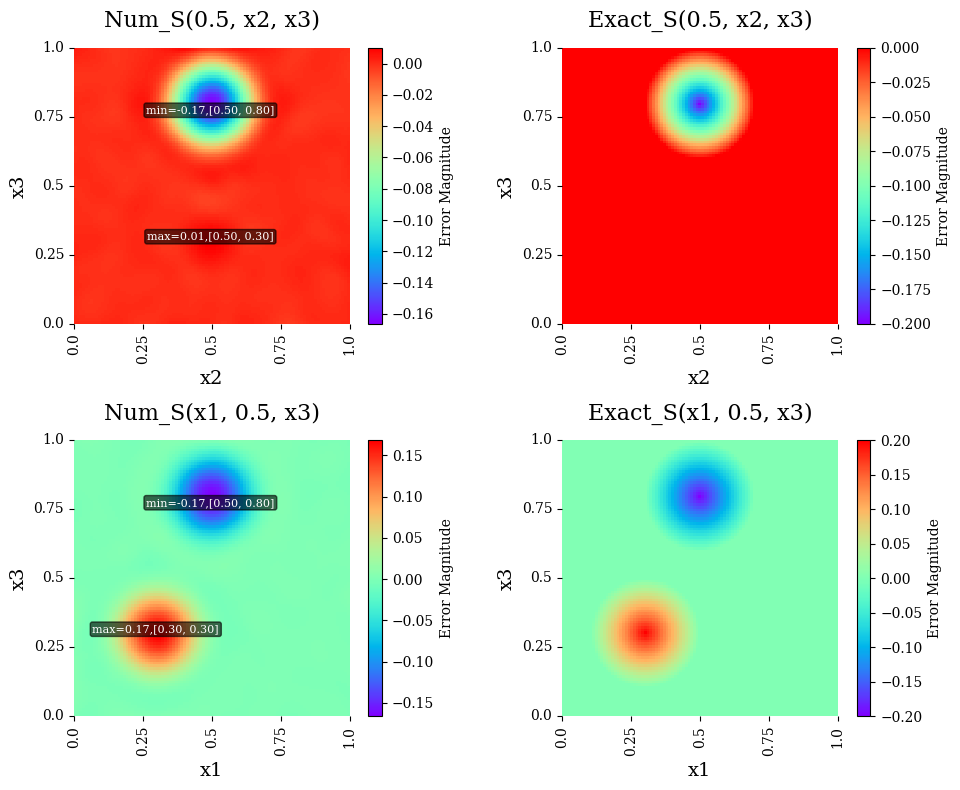

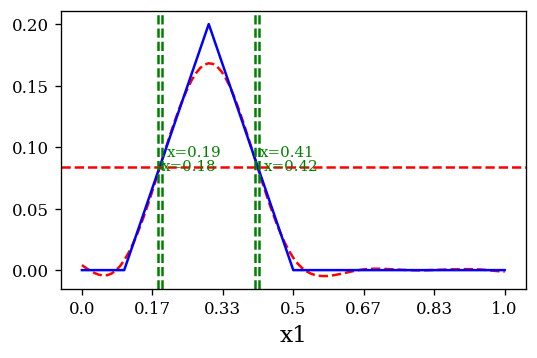

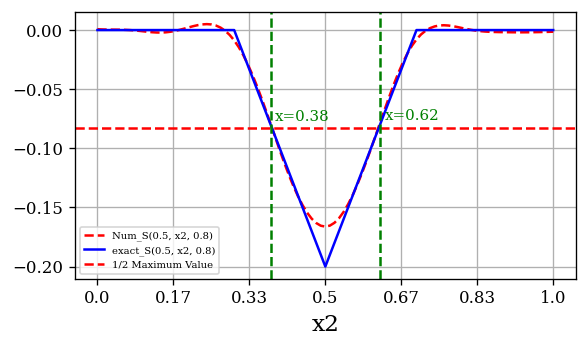

第 2 次自适应网格细分...
S_l_inf= 0.851670341776331 S_L_2= 0.00239185540681641 S_l_2= 0.0864736056652998
S_l_inf= 1.025018743557686 S_L_2= 0.002354861885131666 S_l_2= 0.0851586802335615
当前总网格数目: 2325
Visualization failed: name 'MeshVisualizer' is not defined


In [8]:
Ix,Iy,Iz=4,4,4  #x方向网格点
nx,ny,nz=3,3,3  #每个网格x方向的高斯点
cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
delta=10**(-3)
lamb_regu=np.logspace(-1,-1,3)

Qx,Qy,Qz=50,50,50
iter_int=3
max_level=4
current_maxiter=1
#refine_threshold_S=[1e-4, 5e-4, 1e-3, 5e-3, 1e-2] #刚开始阈值小多细分，后面阈值大少细分
refine_threshold_S=[1e-6, 5e-6, 1e-5, 5e-5, 1e-4] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-7, 1e-7, 8e-7, 8e-7, 8e-7] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-8, 1e-8, 1e-7, 1e-7, 1e-6] #刚开始阈值小多细分，后面阈值大少细分
refine_threshold_grad=[5e-9, 1e-8, 5e-8, 1e-7, 5e-7]
refine_threshold_noise=[5e-5,5e-5,5e-5,5e-5,5e-5,5e-5]
ratio1=[0.3,0.5,0.3]
ratio2=[0.5,0.5,0.8]
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_num_store,S_basis=main_fix.ada_int(iter_int,delta,cells,nx,models0,M,"Tanh",kk,F_81_5_15,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,Qz,ratio1,ratio2,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)

In [ ]:
import pickle
output_pickle_file = "./noise=5%/cells_store.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(cells_store,f)

In [ ]:
np.save("./noise=5%/S_basis.npy",S_basis)
np.save("./noise=5%/g_S.npy",g_S)

Grid shape from g_S: 101x101x101
Number of detected clusters: 2
Cluster 0: L=(0.42, 0.42, 0.42), AR=1.00
  Res_Box=0.194 vs Res_Ellip=0.035
  -> Decision: Sphere
  CV of S_num: 0.775
    Rect Residual: 0.1939, Ellip Residual: 0.0346
    Aspect Ratio: 1.000
    Curvature - Std: 0.0352, Mean: 0.0990, Peak Ratio: 2.02
Cluster 1: L=(0.41, 0.41, 0.35), AR=1.17
  Res_Box=0.158 vs Res_Ellip=0.070
  -> Decision: Sphere
  CV of S_num: 0.758
    Rect Residual: 0.1578, Ellip Residual: 0.0702
    Aspect Ratio: 1.171
    Curvature - Std: 0.0437, Mean: 0.0912, Peak Ratio: 2.27


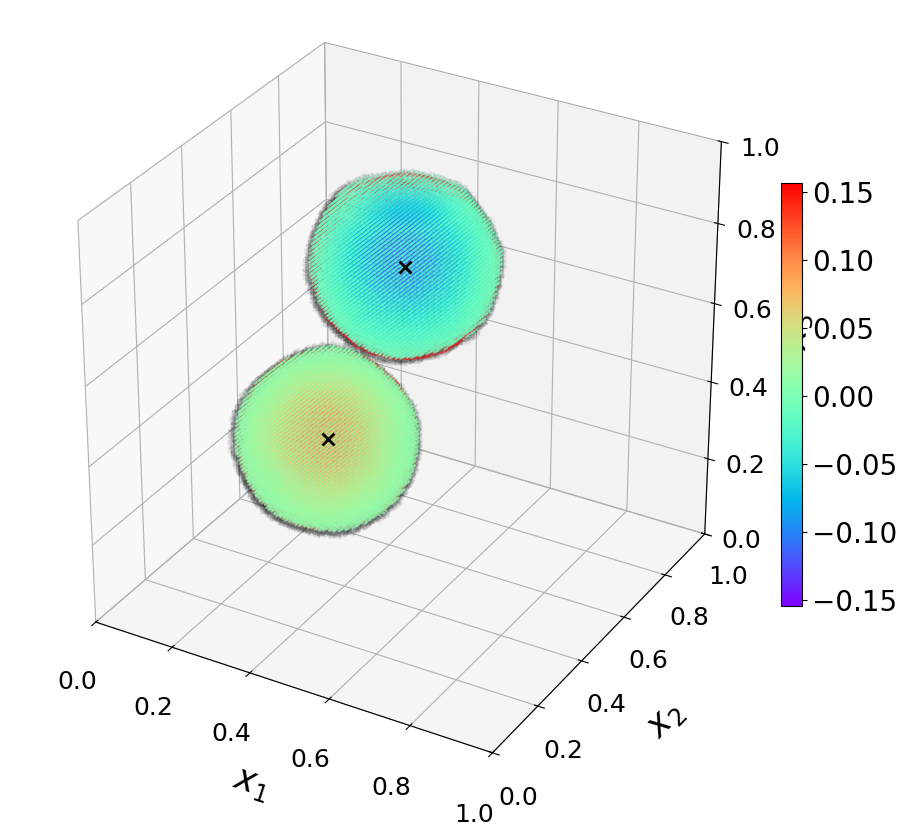

In [ ]:
from importlib import reload
import Bound_detect3D
reload(Bound_detect3D)

# 动态获取 g_S 的形状，确保维度匹配
nx, ny, nz = g_S.shape
print(f"Grid shape from g_S: {nx}x{ny}x{nz}")

x = np.linspace(tau_x_min, tau_x_max, nx)
y = np.linspace(tau_y_min, tau_y_max, ny)
z = np.linspace(tau_z_min, tau_z_max, nz)

# 关键：使用 indexing='ij' 以匹配矩阵索引 (row, col, depth) -> (x, y, z)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

eps_cluster=0.02
mini_samples=20 
para_abs=100
para_grad=3

results = Bound_detect3D.detect_shape_3d(
    g_S, X, Y, Z, 
    tau_x_min, tau_x_max, tau_y_min, tau_y_max, tau_z_min, tau_z_max,
    para_abs, para_grad, eps_cluster, mini_samples, 
    S_num_store[-1], 
    output_directory="./noise=5%", 
    output_filename="plot.png"
)

In [25]:
results

[{'cluster_id': 0,
  'shape': 'Sphere',
  'params': {'center': array([0.29984984, 0.49992826, 0.30033369]),
   'radius': 0.20141723199679232},
  'profile': 'Exp'},
 {'cluster_id': 1,
  'shape': 'Sphere',
  'params': {'center': array([0.49986397, 0.49965605, 0.79187622]),
   'radius': 0.20177814404393138},
  'profile': 'Exp'}]

In [26]:
center0=results[0]['params']['center']
r0=results[0]['params']['radius']
center1=results[1]['params']['center']
r1=results[1]['params']['radius']


In [14]:
FWHM1=0.24
v1=-(2.355)**2/(2*FWHM1)
FWHM2=0.22
v2=-(2.355)**2/(2*FWHM2)

In [14]:
v1,v2

(-11.55421875, -12.604602272727274)

In [15]:
v_max = np.max(np.abs([v1, v2]))*2
v_min = np.min(np.abs([v1, v2]))*1/2

In [16]:
R_m=10
eps_c=0.05
eps_r=0.05
b1_min1,b1_max1=-center0[0]*(1+eps),-center0[0]*(1-eps)
b2_min1,b2_max1=-center0[1]*(1+eps),-center0[1]*(1-eps)
b3_min1,b3_max1=-center0[2]*(1+eps),-center0[2]*(1-eps)
b1_min2,b1_max2=-center1[0]*(1+eps),-center1[0]*(1-eps)
b2_min2,b2_max2=-center1[1]*(1+eps),-center1[1]*(1-eps)
b3_min2,b3_max2=-center1[2]*(1+eps),-center1[2]*(1-eps)
r1_min,r1_max=r0*(1-eps_r),r0*(1+eps_r)
r2_min,r2_max=r1*(1-eps_r),r1*(1+eps_r)
K_min,K_max=0,100
v_min = -np.max(np.abs([v1, v2]))*2
v_max = -np.min(np.abs([v1, v2]))*1/2
model_relu1 = net_3D_fix.local_rep(in_features=3, out_features=1, hidden_layers=1, M=900, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=r1_min, r_max=r1_max,b1_min=b1_min1,b1_max=b1_max1,b2_min=b2_min1,b2_max=b2_max1,b3_min=b3_min1,b3_max=b3_max1,peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="relu",device=device).to(device)
model_relu2 = net_3D_fix.local_rep(in_features=3, out_features=1, hidden_layers=1, M=900, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=r2_min, r_max=r2_max,b1_min=b1_min2,b1_max=b1_max2,b2_min=b2_min2,b2_max=b2_max2,b3_min=b3_min2,b3_max=b3_max2,peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="relu",device=device).to(device)
model_gauss1 =  net_3D_fix.local_rep(in_features=3, out_features=1, hidden_layers=1, M=900, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=r1_min, r_max=r1_max,b1_min=b1_min2,b1_max=b1_max2,b2_min=b2_min2,b2_max=b2_max2,b3_min=b3_min2,b3_max=b3_max2,peak_min=[],peak_max=[],v_min=v_min,v_max=v_max,K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="Gauss",device=device).to(device)
model_gauss2 =  net_3D_fix.local_rep(in_features=3, out_features=1, hidden_layers=1, M=900, x_max=1, x_min=0, y_max=1, y_min=0,z_min=0,z_max=1, r_min=r2_min, r_max=r2_max,b1_min=b1_min2,b1_max=b1_max2,b2_min=b2_min2,b2_max=b2_max2,b3_min=b3_min2,b3_max=b3_max2,peak_min=[],peak_max=[],v_min=v_min,v_max=v_max,K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="Gauss",device=device).to(device)

In [17]:
S_basis.shape

(38772, 3600)

In [18]:
sum_mat,all_g_p1,all_g_n,cells_copy1,S_basis_1=cal_S_grad.mat_assemble2(cells_store[-1],models0,model_relu1,model_relu2,model_gauss1,model_gauss2,S_basis,"mixer",kk,0,points_b,device,cupy_device)

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


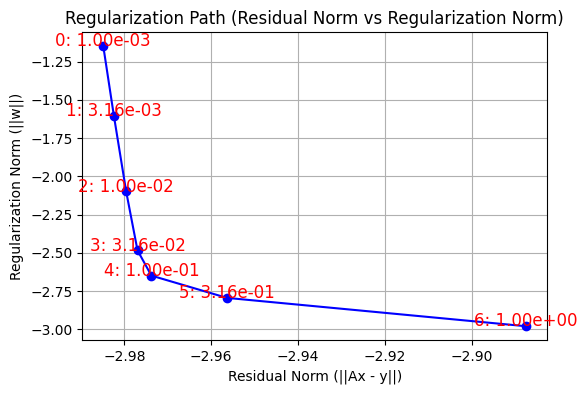

In [19]:
lamb_regu=np.logspace(-3,0,7,endpoint=True)
M0=models0.M
M_relu1,M_relu2=model_relu1.M,model_relu2.M
M_gauss1,M_gauss2=model_gauss1.M,model_gauss2.M
res,reg_norm,w_store=org_m.L_curve(M0,M_relu1,M_relu2,M_gauss1,M_gauss2,"mixer",sum_mat,F_81_5_15,lamb_regu,cupy_device) #先进行求解

In [20]:
Qx,Qy,Qz=150,150,150
sample_s=error_general_3D.test_p(Qx,Qy,Qz,0,1,0,1,0,1)
ratio1=[0.3,0.5,0.3]
ratio2=[0.5,0.5,0.8]

lamb: 0.0001
S_l_inf= 0.5220698821003601 S_L_2= 0.0002025118627996229 S_l_2= 0.012430368686568074


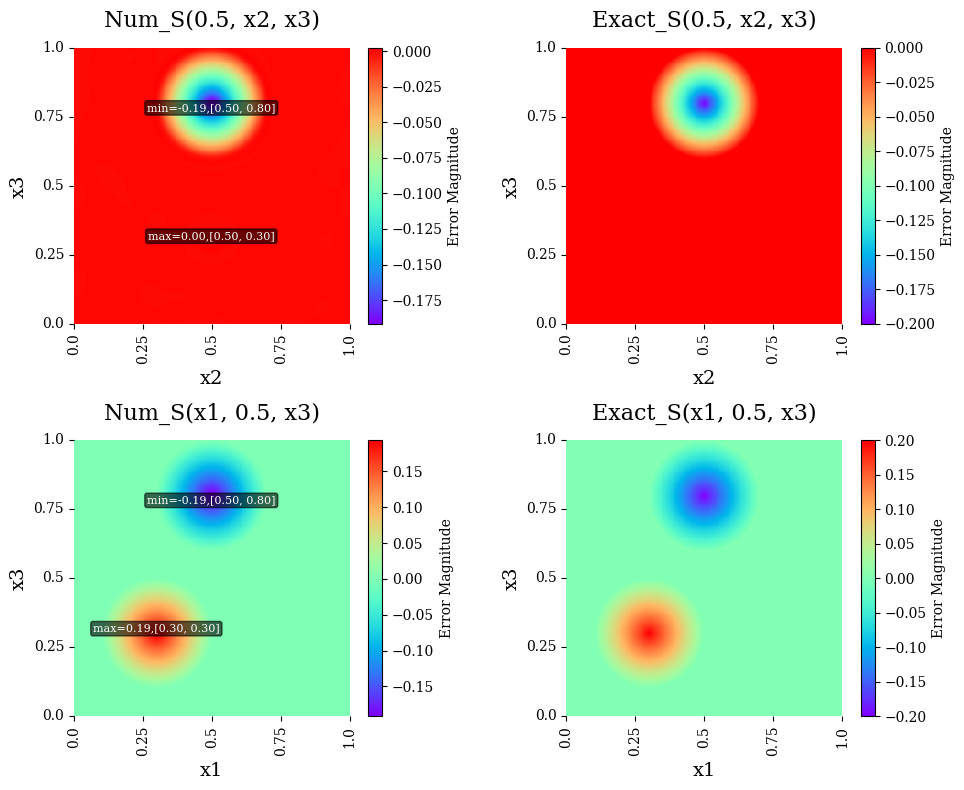

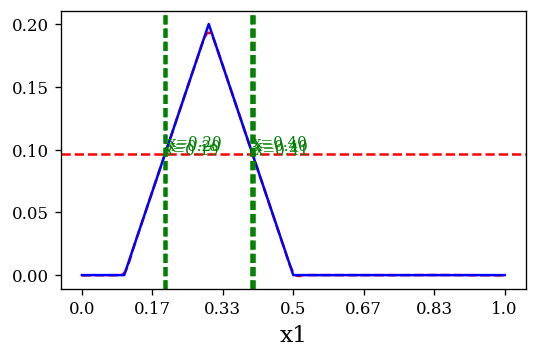

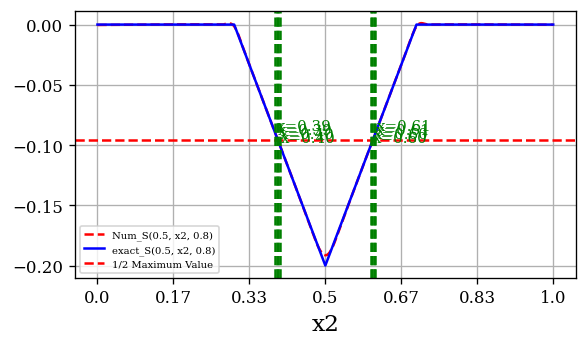

In [ ]:
lamb=lamb_regu[3]**2
print('lamb:',lamb)
S_num,S_true,S_l_inf,S_l_2,g_S=error_general_3D.test(models0,model_relu1,model_relu2,model_gauss1,model_gauss2,sample_s,w_store[:,3],"mixer",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,tau_z_min,tau_z_max,[],[],[],[],center_true,r_true,ana_S,0,ratio1,ratio2,device)

In [ ]:
torch.save(model_relu1, f"./noise=5%/models_relu1_{lamb}.pth")
torch.save(model_relu2, f"./noise=5%/models_relu2_{lamb}.pth")
torch.save(model_gauss1, f"./noise=5%/models_gauss1_{lamb}.pth")
torch.save(model_gauss2, f"./noise=5%/models_gauss2_{lamb}.pth")

In [ ]:
np.save(f"./noise=5%/S_num_{lamb}.npy",S_num)
np.save(f"./noise=5%/w_store_{lamb}.npy",w_store)
np.save(f"./noise=5%/sum_mat_{lamb}.npy",sum_mat)

In [ ]:
n_integral=len(cells_store[-1])*27
print('n_integral:',n_integral)
print('center1[0]:',center0)
print('center2[1]:',center1)
print('r1:',r0)
print('r2:',r1)
print('lamb_regu:',lamb)
print('S_l21:',S_l_2)

n_integral: 38772
center1[0]: [0.29984818 0.49992798 0.30034535]
center2[1]: [0.49993043 0.49965242 0.7918808 ]
r1: 0.20142146087333732
r2: 0.201812825532726
lamb_regu: 0.0009999999999999998
S_l21: 0.012430368686568074
